# Predicción de supervivencia en el Titanic

## tl;dr

**Resultado principal.** El criterio definido antes de evaluar prueba seleccionó **HistGradientBoosting**, con F1 promedio de validación cruzada de **0.759 ± 0.033** y ROC-AUC promedio de **0.877 ± 0.019**.

**Evaluación final.** En las 179 observaciones de prueba obtuvo exactitud **0.810**, precisión **0.787**, sensibilidad **0.696**, F1 **0.738** y ROC-AUC **0.814**.

**Diagnóstico.** La diferencia entre F1 de entrenamiento (0.898) y prueba (0.738) fue **+0.160**, por lo que se observan **indicios de sobreajuste**. El modelo es útil como comparación académica, pero requiere regularización y validación adicional antes de cualquier uso real.

**Fuente.** `Titanic-Dataset.csv`, 891 pasajeros y 12 variables originales.


## Contexto y métodos

La variable objetivo es `Survived`: `0` indica que el pasajero no sobrevivió y `1` que sobrevivió. El trabajo compara cinco clasificadores con la misma estrategia de preprocesamiento y conserva el conjunto de prueba únicamente para la evaluación final.

### Supuestos clave

- La fila representa a un pasajero.
- El CSV proporcionado es la fuente de verdad del ejercicio.
- La evaluación es predictiva, no causal.
- La selección del mejor modelo se realiza con F1 promedio de validación cruzada sobre entrenamiento; ROC-AUC y menor variabilidad funcionan como desempates.
- La prueba 20 % no se usa para ajustar hiperparámetros ni seleccionar el modelo.

## Datos

### 1. Configuración e importaciones

Se fijan la semilla, las rutas y el estilo de las visualizaciones. Los artefactos derivados se guardan en `resultados/`.

In [1]:
from pathlib import Path
import json
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "Titanic-Dataset.csv"
RESULTS_DIR = BASE_DIR / "resultados"
RESULTS_DIR.mkdir(exist_ok=True)

assert DATA_PATH.exists(), (
    "No se encontró Titanic-Dataset.csv. Coloque el CSV en la misma carpeta "
    "que este notebook y ejecute nuevamente."
)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "blue": "#5477C4",
    "gold": "#B8A037",
    "orange": "#CC6F47",
    "olive": "#71B436",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
}

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"Archivo de datos: {DATA_PATH.name}")

Python: 3.12.13
pandas: 2.2.3
scikit-learn: 1.5.2
Archivo de datos: Titanic-Dataset.csv


### 2. Carga y exploración inicial

Se revisan dimensiones, muestra de registros, tipos, duplicados y estadística descriptiva. Esta sección cubre los puntos 1, 2 y 3 de los entregables del notebook.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Filas duplicadas completas: {df.duplicated().sum()}")
display(df.head())

tipos_variables = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": [df[col].nunique(dropna=True) for col in df.columns],
})
display(tipos_variables)
display(df.describe(include="all").T)

assert df.shape == (891, 12), f"Dimensión inesperada: {df.shape}"
assert df.duplicated().sum() == 0, "Se encontraron filas duplicadas completas."

Dimensiones: 891 filas x 12 columnas
Filas duplicadas completas: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,variable,tipo,valores_unicos
0,PassengerId,int64,891
1,Survived,int64,2
2,Pclass,int64,3
3,Name,object,891
4,Sex,object,2
5,Age,float64,88
6,SibSp,int64,7
7,Parch,int64,7
8,Ticket,object,681
9,Fare,float64,248


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


### 3. Valores faltantes

La imputación todavía no se aplica. Aquí solo se diagnostica; el ajuste de imputadores ocurrirá dentro de cada pipeline durante entrenamiento y validación cruzada.

In [3]:
faltantes = (
    pd.DataFrame({
        "faltantes": df.isna().sum(),
        "porcentaje": (df.isna().mean() * 100).round(2),
    })
    .query("faltantes > 0")
    .sort_values("faltantes", ascending=False)
)
display(faltantes)

esperados = {"Age": 177, "Cabin": 687, "Embarked": 2}
observados = df.isna().sum().to_dict()
for columna, cantidad in esperados.items():
    assert observados[columna] == cantidad, (
        f"Faltantes inesperados en {columna}: {observados[columna]}"
    )

,faltantes,porcentaje
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


### 4. Distribución de `Survived`

La estratificación será obligatoria porque las clases no tienen la misma frecuencia.

,clase,cantidad,porcentaje
0,No sobrevivió,549,61.62
1,Sobrevivió,342,38.38


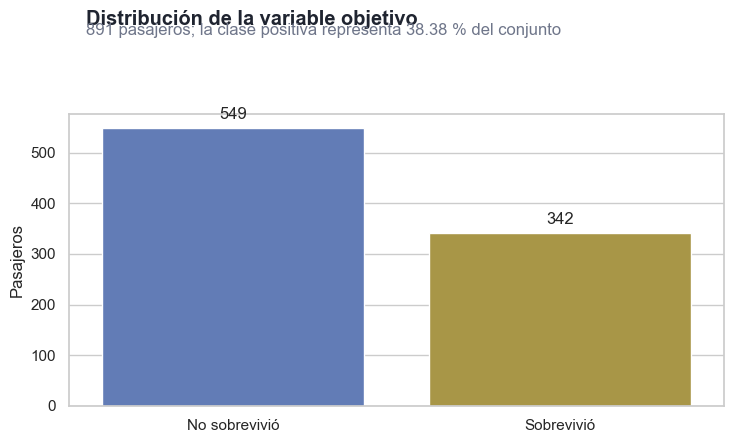

In [4]:
distribucion_objetivo = (
    df["Survived"]
    .value_counts()
    .sort_index()
    .rename_axis("Survived")
    .reset_index(name="cantidad")
)
distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["cantidad"] / len(df) * 100
).round(2)
distribucion_objetivo["clase"] = distribucion_objetivo["Survived"].map(
    {0: "No sobrevivió", 1: "Sobrevivió"}
)
display(distribucion_objetivo[["clase", "cantidad", "porcentaje"]])

assert distribucion_objetivo.set_index("Survived")["cantidad"].to_dict() == {0: 549, 1: 342}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(
    data=distribucion_objetivo,
    x="clase",
    y="cantidad",
    hue="clase",
    palette=[PALETTE["blue"], PALETTE["gold"]],
    legend=False,
    ax=ax,
)
fig.suptitle(
    "Distribución de la variable objetivo",
    x=0.125,
    y=0.98,
    ha="left",
    weight="bold",
    color=PALETTE["ink"],
)
fig.text(
    0.125,
    0.925,
    "891 pasajeros; la clase positiva representa 38.38 % del conjunto",
    color=PALETTE["muted"],
)
ax.set_xlabel("")
ax.set_ylabel("Pasajeros")
ax.grid(axis="x", visible=False)
for container in ax.containers:
    ax.bar_label(container, padding=4)
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(RESULTS_DIR / "distribucion_survived.png", dpi=200, bbox_inches="tight")
plt.show()

### 5. Selección de variables y separación de la variable objetivo

**Variables numéricas:** `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`.

**Variables categóricas:** `Sex`, `Embarked`.

**Exclusiones justificadas:**

- `PassengerId`: identificador sin significado predictivo generalizable.
- `Name`: texto de alta cardinalidad; su transformación requeriría ingeniería de características fuera del alcance base.
- `Ticket`: alta cardinalidad y formato heterogéneo.
- `Cabin`: 687 valores faltantes (77.10 %) y alta cardinalidad.

Esta selección evita incorporar identificadores o transformaciones no exigidas y permite comparar los modelos bajo un flujo común.

In [5]:
NUMERIC_FEATURES = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
CATEGORICAL_FEATURES = ["Sex", "Embarked"]
SELECTED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
EXCLUDED_FEATURES = ["PassengerId", "Name", "Ticket", "Cabin"]
TARGET = "Survived"

X = df[SELECTED_FEATURES].copy()
y = df[TARGET].copy()

print("Predictores:", SELECTED_FEATURES)
print("Variables excluidas:", EXCLUDED_FEATURES)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

assert TARGET not in X.columns
assert set(X.columns) == set(SELECTED_FEATURES)

Predictores: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']
Variables excluidas: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Forma de X: (891, 7)
Forma de y: (891,)


### 6. Partición estratificada 80/20

La semilla fija permite reproducir exactamente la separación. La estratificación conserva aproximadamente la proporción de supervivencia en ambos subconjuntos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

particiones = pd.DataFrame({
    "particion": ["Total", "Entrenamiento", "Prueba"],
    "filas": [len(y), len(y_train), len(y_test)],
    "porcentaje_clase_1": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_test.mean() * 100,
    ],
})
particiones["porcentaje_clase_1"] = particiones["porcentaje_clase_1"].round(2)
display(particiones)

assert len(X_train) == 712
assert len(X_test) == 179
assert abs(y_train.mean() - y_test.mean()) < 0.01

,particion,filas,porcentaje_clase_1
0,Total,891,38.38
1,Entrenamiento,712,38.34
2,Prueba,179,38.55


## Resultados

### 7. Preprocesamiento reproducible con `ColumnTransformer`

- Las variables numéricas se imputan con la media y se escalan.
- Las categóricas se imputan con `Unknown` y se codifican con one-hot.
- `handle_unknown="ignore"` permite procesar categorías nuevas.
- Todo el preprocesamiento queda dentro del `Pipeline`, por lo que cada ajuste ocurre únicamente con los datos de entrenamiento del fold correspondiente.

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, NUMERIC_FEATURES),
        ("categorical", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked'])])

### 8. Definición de los cinco modelos

La regresión logística funciona como línea base interpretable. KNN aporta una referencia no paramétrica. El árbol ofrece reglas legibles con profundidad restringida. El bosque aleatorio reduce la inestabilidad de un solo árbol. HistGradientBoosting es adecuado para datos tabulares y modela relaciones no lineales mediante un ensamble secuencial eficiente.

In [8]:
MODELS = {
    "Regresión logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K vecinos": KNeighborsClassifier(n_neighbors=7),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    ),
    "Bosque aleatorio": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model),
        ]
    )
    for name, model in MODELS.items()
}

print("Modelos definidos:")
for name in pipelines:
    print(f"- {name}")

Modelos definidos:
- Regresión logística
- K vecinos
- Árbol de decisión
- Bosque aleatorio
- HistGradientBoosting


### 9. Validación cruzada estratificada

La validación usa cinco particiones únicamente sobre el conjunto de entrenamiento. Se reportan media y desviación estándar de F1 y ROC-AUC para medir desempeño y estabilidad.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []
for model_name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    cv_rows.append({
        "modelo": model_name,
        "cv_f1_media": scores["test_f1"].mean(),
        "cv_f1_std": scores["test_f1"].std(),
        "cv_roc_auc_media": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    by=["cv_f1_media", "cv_roc_auc_media", "cv_f1_std"],
    ascending=[False, False, True],
).reset_index(drop=True)

cv_results.to_csv(RESULTS_DIR / "validacion_cruzada.csv", index=False)
display(cv_results.style.format({
    "cv_f1_media": "{:.3f}",
    "cv_f1_std": "{:.3f}",
    "cv_roc_auc_media": "{:.3f}",
    "cv_roc_auc_std": "{:.3f}",
}))

C:\Users\LINKZ\OneDrive\Escritorio\P25 JAVA RMI\titanic_build\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\LINKZ\OneDrive\Escritorio\P25 JAVA RMI\titanic_build\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,modelo,cv_f1_media,cv_f1_std,cv_roc_auc_media,cv_roc_auc_std
0,HistGradientBoosting,0.759,0.033,0.877,0.019
1,Bosque aleatorio,0.737,0.024,0.871,0.019
2,Regresión logística,0.726,0.034,0.855,0.021
3,Árbol de decisión,0.721,0.013,0.843,0.023
4,K vecinos,0.720,0.026,0.850,0.025


### 10. Entrenamiento y evaluación de los cinco modelos

Cada pipeline se ajusta con entrenamiento. Se calculan exactitud, precisión, sensibilidad, F1 y ROC-AUC tanto en entrenamiento como en prueba.

In [10]:
def evaluate_split(model, features, target, split_name):
    predictions = model.predict(features)
    probabilities = model.predict_proba(features)[:, 1]
    return {
        "split": split_name,
        "accuracy": accuracy_score(target, predictions),
        "precision": precision_score(target, predictions, zero_division=0),
        "recall": recall_score(target, predictions, zero_division=0),
        "f1": f1_score(target, predictions, zero_division=0),
        "roc_auc": roc_auc_score(target, probabilities),
    }


metric_rows = []
for model_name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    train_metrics = evaluate_split(pipeline, X_train, y_train, "entrenamiento")
    test_metrics = evaluate_split(pipeline, X_test, y_test, "prueba")
    metric_rows.extend([
        {"modelo": model_name, **train_metrics},
        {"modelo": model_name, **test_metrics},
    ])

metrics_long = pd.DataFrame(metric_rows)
metrics_long.to_csv(RESULTS_DIR / "metricas_modelos.csv", index=False)

test_metrics = metrics_long.query("split == 'prueba'").drop(columns="split")
comparison = test_metrics.merge(cv_results, on="modelo", how="left")
comparison = comparison.sort_values(
    by=["cv_f1_media", "cv_roc_auc_media", "cv_f1_std"],
    ascending=[False, False, True],
).reset_index(drop=True)
comparison.to_csv(RESULTS_DIR / "comparacion_modelos.csv", index=False)

display(comparison.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "roc_auc": "{:.3f}",
    "cv_f1_media": "{:.3f}",
    "cv_f1_std": "{:.3f}",
    "cv_roc_auc_media": "{:.3f}",
    "cv_roc_auc_std": "{:.3f}",
}))

,modelo,accuracy,precision,recall,f1,roc_auc,cv_f1_media,cv_f1_std,cv_roc_auc_media,cv_roc_auc_std
0,HistGradientBoosting,0.810,0.787,0.696,0.738,0.814,0.759,0.033,0.877,0.019
1,Bosque aleatorio,0.810,0.830,0.638,0.721,0.846,0.737,0.024,0.871,0.019
2,Regresión logística,0.804,0.793,0.667,0.724,0.845,0.726,0.034,0.855,0.021
3,Árbol de decisión,0.760,0.732,0.594,0.656,0.792,0.721,0.013,0.843,0.023
4,K vecinos,0.810,0.787,0.696,0.738,0.859,0.720,0.026,0.850,0.025


### 11. Comparación visual del desempeño

La tabla anterior contiene los valores exactos. El gráfico facilita comparar exactitud, F1 y ROC-AUC de prueba sin interpretar la exactitud de forma aislada.

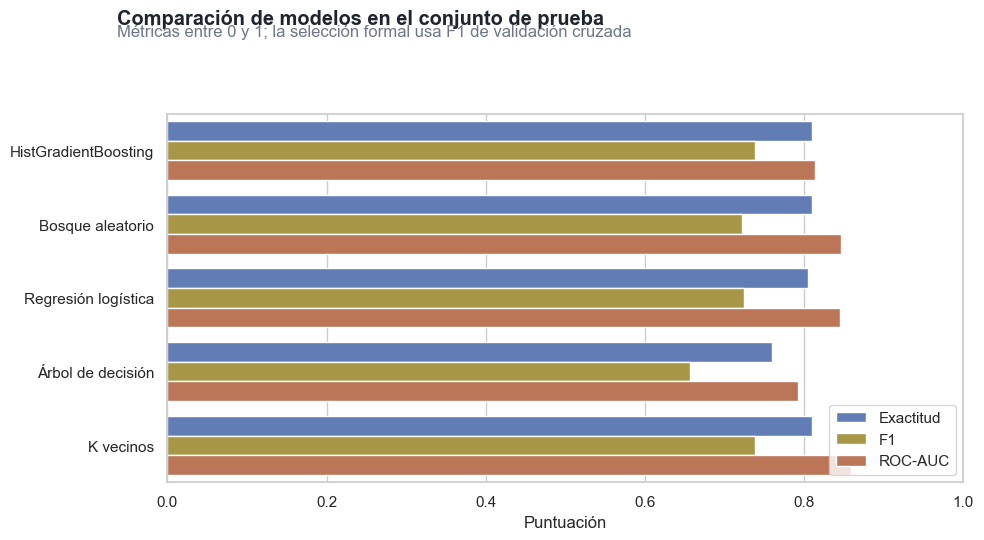

In [11]:
plot_metrics = (
    comparison[["modelo", "accuracy", "f1", "roc_auc"]]
    .melt(id_vars="modelo", var_name="metrica", value_name="valor")
)
metric_labels = {
    "accuracy": "Exactitud",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
}
plot_metrics["metrica"] = plot_metrics["metrica"].map(metric_labels)

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_metrics,
    x="valor",
    y="modelo",
    hue="metrica",
    palette=[PALETTE["blue"], PALETTE["gold"], PALETTE["orange"]],
    ax=ax,
)
fig.suptitle(
    "Comparación de modelos en el conjunto de prueba",
    x=0.125,
    y=0.98,
    ha="left",
    weight="bold",
    color=PALETTE["ink"],
)
fig.text(
    0.125,
    0.93,
    "Métricas entre 0 y 1; la selección formal usa F1 de validación cruzada",
    color=PALETTE["muted"],
)
ax.set_xlabel("Puntuación")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(title="", loc="lower right")
fig.tight_layout(rect=[0, 0, 1, 0.89])
fig.savefig(RESULTS_DIR / "comparacion_modelos.png", dpi=200, bbox_inches="tight")
plt.show()

### 12. Selección del mejor modelo

El criterio de selección es reproducible: mayor F1 promedio de validación cruzada, después mayor ROC-AUC promedio y finalmente menor desviación estándar de F1.

In [12]:
best_model_name = comparison.iloc[0]["modelo"]
best_pipeline = pipelines[best_model_name]
best_test_row = comparison.iloc[0]

print(f"Mejor modelo según validación cruzada: {best_model_name}")
print(f"F1 CV: {best_test_row['cv_f1_media']:.3f} ± {best_test_row['cv_f1_std']:.3f}")
print(f"ROC-AUC CV: {best_test_row['cv_roc_auc_media']:.3f} ± {best_test_row['cv_roc_auc_std']:.3f}")
print(f"F1 prueba: {best_test_row['f1']:.3f}")
print(f"ROC-AUC prueba: {best_test_row['roc_auc']:.3f}")

Mejor modelo según validación cruzada: HistGradientBoosting
F1 CV: 0.759 ± 0.033
ROC-AUC CV: 0.877 ± 0.019
F1 prueba: 0.738
ROC-AUC prueba: 0.814


### 13. Matriz de confusión del mejor modelo

Las filas representan la clase real y las columnas la predicción. Esto permite distinguir falsos positivos y falsos negativos.

,Predicción: no sobrevivió,Predicción: sobrevivió
Real: no sobrevivió,97,13
Real: sobrevivió,21,48


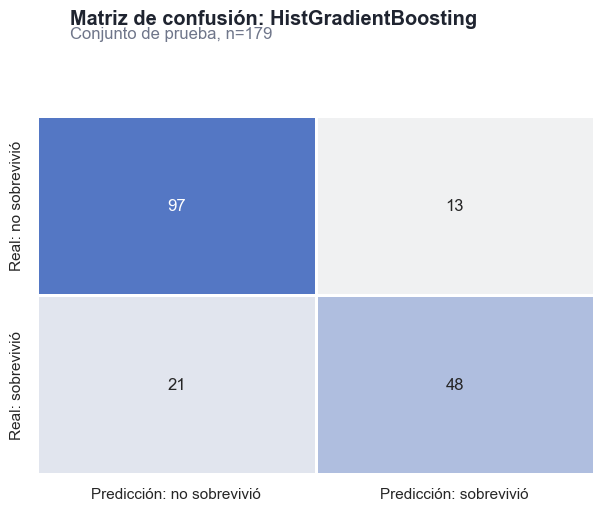

In [13]:
best_predictions = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, best_predictions)
tn, fp, fn, tp = cm.ravel()

confusion_df = pd.DataFrame(
    cm,
    index=["Real: no sobrevivió", "Real: sobrevivió"],
    columns=["Predicción: no sobrevivió", "Predicción: sobrevivió"],
)
display(confusion_df)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
sns.heatmap(
    confusion_df,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(PALETTE["blue"], as_cmap=True),
    cbar=False,
    linewidths=1,
    linecolor="white",
    ax=ax,
)
fig.suptitle(
    f"Matriz de confusión: {best_model_name}",
    x=0.125,
    y=0.98,
    ha="left",
    weight="bold",
    color=PALETTE["ink"],
)
fig.text(
    0.125,
    0.925,
    f"Conjunto de prueba, n={len(y_test)}",
    color=PALETTE["muted"],
)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(RESULTS_DIR / "matriz_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

### 14. Comparación entre entrenamiento y prueba

Una diferencia amplia a favor de entrenamiento indicaría sobreajuste. Un desempeño bajo en ambos subconjuntos sugeriría subajuste.

split,modelo,entrenamiento,prueba,brecha_f1
1,HistGradientBoosting,0.898,0.738,+0.160
4,Árbol de decisión,0.802,0.656,+0.146
0,Bosque aleatorio,0.858,0.721,+0.136
2,K vecinos,0.788,0.738,+0.050
3,Regresión logística,0.739,0.724,+0.015


HistGradientBoosting: F1 entrenamiento=0.898, F1 prueba=0.738, brecha=+0.160. Evaluación: indicios de sobreajuste.


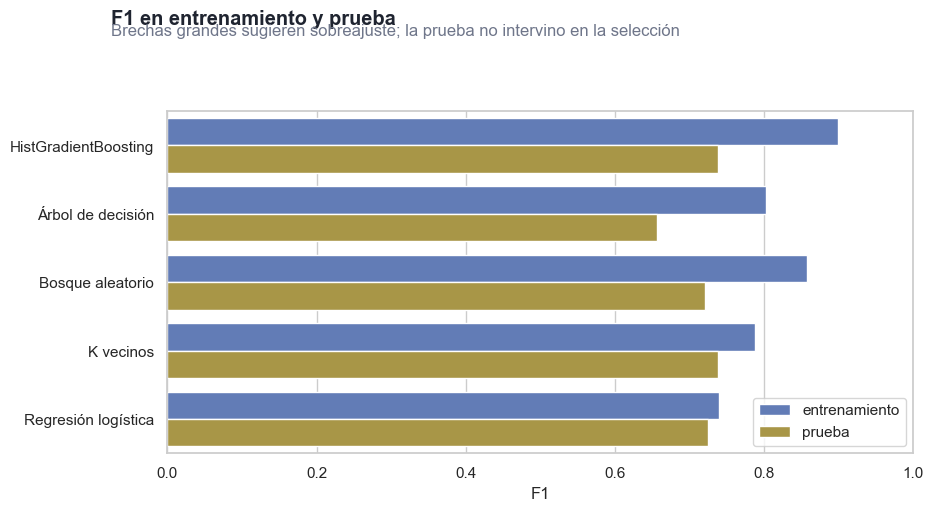

In [14]:
train_test_f1 = metrics_long.pivot(index="modelo", columns="split", values="f1").reset_index()
train_test_f1["brecha_f1"] = train_test_f1["entrenamiento"] - train_test_f1["prueba"]
train_test_f1 = train_test_f1.sort_values("brecha_f1", ascending=False)
train_test_f1.to_csv(RESULTS_DIR / "comparacion_train_test.csv", index=False)
display(train_test_f1.style.format({
    "entrenamiento": "{:.3f}",
    "prueba": "{:.3f}",
    "brecha_f1": "{:+.3f}",
}))

best_gap = float(
    train_test_f1.loc[train_test_f1["modelo"] == best_model_name, "brecha_f1"].iloc[0]
)
best_train_f1 = float(
    train_test_f1.loc[train_test_f1["modelo"] == best_model_name, "entrenamiento"].iloc[0]
)
best_test_f1 = float(
    train_test_f1.loc[train_test_f1["modelo"] == best_model_name, "prueba"].iloc[0]
)

if best_train_f1 < 0.65 and best_test_f1 < 0.65:
    fit_assessment = "posible subajuste"
elif best_gap > 0.10:
    fit_assessment = "indicios de sobreajuste"
else:
    fit_assessment = "ajuste razonable"

print(
    f"{best_model_name}: F1 entrenamiento={best_train_f1:.3f}, "
    f"F1 prueba={best_test_f1:.3f}, brecha={best_gap:+.3f}. "
    f"Evaluación: {fit_assessment}."
)

plot_train_test = train_test_f1.melt(
    id_vars="modelo",
    value_vars=["entrenamiento", "prueba"],
    var_name="split",
    value_name="f1",
)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.barplot(
    data=plot_train_test,
    x="f1",
    y="modelo",
    hue="split",
    palette=[PALETTE["blue"], PALETTE["gold"]],
    ax=ax,
)
fig.suptitle(
    "F1 en entrenamiento y prueba",
    x=0.125,
    y=0.98,
    ha="left",
    weight="bold",
    color=PALETTE["ink"],
)
fig.text(
    0.125,
    0.93,
    "Brechas grandes sugieren sobreajuste; la prueba no intervino en la selección",
    color=PALETTE["muted"],
)
ax.set_xlabel("F1")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(title="")
fig.tight_layout(rect=[0, 0, 1, 0.89])
fig.savefig(RESULTS_DIR / "comparacion_train_test.png", dpi=200, bbox_inches="tight")
plt.show()

### 15. Prueba con categorías no observadas

Se altera una fila de prueba con categorías que no aparecieron durante entrenamiento. La predicción debe completarse sin error gracias a `handle_unknown="ignore"`.

In [15]:
unseen_example = X_test.iloc[[0]].copy()
unseen_example["Sex"] = "categoria_nueva"
unseen_example["Embarked"] = "X"
unseen_prediction = int(best_pipeline.predict(unseen_example)[0])
unseen_probability = float(best_pipeline.predict_proba(unseen_example)[0, 1])

print("Predicción completada con categorías nuevas.")
print(f"Clase predicha: {unseen_prediction}")
print(f"Probabilidad estimada de supervivencia: {unseen_probability:.3f}")

assert unseen_prediction in (0, 1)
assert 0 <= unseen_probability <= 1

Predicción completada con categorías nuevas.
Clase predicha: 0
Probabilidad estimada de supervivencia: 0.165


## Conclusiones y recomendaciones

### 16. Conclusión

La conclusión cuantitativa se genera a partir de los resultados ejecutados en la siguiente celda. El modelo elegido no representa una explicación causal de la supervivencia; es una comparación predictiva condicionada por las variables disponibles y por una muestra histórica pequeña.

### Mejoras para una segunda versión

1. Crear `FamilySize = SibSp + Parch + 1` e `IsAlone`.
2. Extraer títulos de `Name` y agrupar categorías infrecuentes.
3. Derivar cubierta o indicador de cabina conocida sin imputar directamente 77 % de valores.
4. Ajustar hiperparámetros con validación cruzada anidada o un conjunto de validación.
5. Calibrar probabilidades y estudiar métricas por sexo y clase para identificar diferencias de desempeño.
6. Mantener el conjunto de prueba bloqueado hasta la evaluación final.

In [16]:
summary = {
    "dataset": {
        "filas": int(df.shape[0]),
        "columnas": int(df.shape[1]),
        "clase_0": int((y == 0).sum()),
        "clase_1": int((y == 1).sum()),
        "faltantes_age": int(df["Age"].isna().sum()),
        "faltantes_cabin": int(df["Cabin"].isna().sum()),
        "faltantes_embarked": int(df["Embarked"].isna().sum()),
    },
    "mejor_modelo": best_model_name,
    "metricas_prueba": {
        "accuracy": float(best_test_row["accuracy"]),
        "precision": float(best_test_row["precision"]),
        "recall": float(best_test_row["recall"]),
        "f1": float(best_test_row["f1"]),
        "roc_auc": float(best_test_row["roc_auc"]),
    },
    "validacion_cruzada": {
        "f1_media": float(best_test_row["cv_f1_media"]),
        "f1_std": float(best_test_row["cv_f1_std"]),
        "roc_auc_media": float(best_test_row["cv_roc_auc_media"]),
        "roc_auc_std": float(best_test_row["cv_roc_auc_std"]),
    },
    "matriz_confusion": {
        "verdaderos_negativos": int(tn),
        "falsos_positivos": int(fp),
        "falsos_negativos": int(fn),
        "verdaderos_positivos": int(tp),
    },
    "ajuste": {
        "f1_entrenamiento": best_train_f1,
        "f1_prueba": best_test_f1,
        "brecha_f1": best_gap,
        "evaluacion": fit_assessment,
    },
    "categoria_no_observada": {
        "estado": "aprobado",
        "prediccion": unseen_prediction,
        "probabilidad": unseen_probability,
    },
    "seleccion": (
        "Mayor F1 promedio de validación cruzada; desempate por mayor ROC-AUC "
        "promedio y menor desviación estándar de F1."
    ),
}

with open(RESULTS_DIR / "resumen_ejecucion.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, ensure_ascii=False, indent=2)

print(
    f"Se selecciona {best_model_name}. En prueba obtuvo F1={best_test_f1:.3f} "
    f"y ROC-AUC={best_test_row['roc_auc']:.3f}. La brecha de F1 respecto a "
    f"entrenamiento fue {best_gap:+.3f}, compatible con {fit_assessment}. "
    "La principal limitación es el tamaño y carácter histórico del conjunto; "
    "los patrones observados no deben interpretarse como relaciones causales."
)
print("Artefactos guardados en:", RESULTS_DIR)

Se selecciona HistGradientBoosting. En prueba obtuvo F1=0.738 y ROC-AUC=0.814. La brecha de F1 respecto a entrenamiento fue +0.160, compatible con indicios de sobreajuste. La principal limitación es el tamaño y carácter histórico del conjunto; los patrones observados no deben interpretarse como relaciones causales.
Artefactos guardados en: C:\Users\LINKZ\OneDrive\Escritorio\P25 JAVA RMI\titanic_build\project\resultados


## Lista de comprobación del paso 8

1. Carga del conjunto de datos: sección 2.
2. Exploración inicial: sección 2.
3. Tipos de variables: sección 2.
4. Valores faltantes: sección 3.
5. Distribución de `Survived`: sección 4.
6. Selección de predictores: sección 5.
7. Separación de `X` e `y`: sección 5.
8. Partición train/test: sección 6.
9. Preprocesamiento con pipeline: sección 7.
10. Entrenamiento de cinco modelos: secciones 8 y 10.
11. Evaluación de cinco modelos: sección 10.
12. Tabla comparativa: sección 10.
13. Selección del mejor modelo: sección 12.
14. Matriz de confusión: sección 13.
15. Comparación entrenamiento/prueba: sección 14.
16. Conclusión: sección 16.